# Eventos de Campo

### 1. Plotting MAPA DE TIROS

In [1]:
pip install understatapi mplsoccer

### Importar librerías

In [2]:
from understatapi import UnderstatClient
import pandas as pd
import numpy as np
from mplsoccer import VerticalPitch, FontManager
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

### Importar datos - Understat

In [3]:
player_id = '8015' #- Rodrygo

In [4]:
understat = UnderstatClient()
player_shot_data = understat.player(player=player_id).get_shot_data() # Get data for every shot from a player in all seasons
df_shots = pd.DataFrame(player_shot_data)

### Transformar datos

In [5]:
def scale_coordinates_dataframe(df, col_x, col_y, original_coord_system_x, original_coord_system_y,
                                target_coord_system_x, target_coord_system_y):
    """
    Scales columns of a DataFrame from an original coordinate system to another coordinate system.

    Parameters:
    - df: pandas DataFrame containing the original data.
    - col_x, col_y: names of the columns in df with the original coordinates.
    - original_coordinate_system_x, original_coordinate_system_y: tuples (min, max) for the original range.
    - target_coordinate_system_x, target_coordinate_system_y: tuples (min, max) for the target range.

    Returns:
    - df with the new scaled columns added.
    """
    xmin_data, xmax_data = original_coord_system_x
    ymin_data, ymax_data = original_coord_system_y
    xmin_new, xmax_new = target_coord_system_x
    ymin_new, ymax_new = target_coord_system_y

    # Normalize and scale
    df[f'{col_x}_scaled'] = ((df[col_x].astype(float) - xmin_data) / (xmax_data - xmin_data)) * (xmax_new - xmin_new) + xmin_new
    df[f'{col_y}_scaled'] = ((df[col_y].astype(float) - ymin_data) / (ymax_data - ymin_data)) * (ymax_new - ymin_new) + ymin_new

    return df

In [6]:
df_shots['xG'] = df_shots['xG'].astype(float)

original_coord_system_x = (0, 1)
original_coord_system_y = (0, 1)
target_coord_system_x = (0, 105)
target_coord_system_y = (0, 68)

df = scale_coordinates_dataframe(df_shots, 'X', 'Y', original_coord_system_x, original_coord_system_y, target_coord_system_x, target_coord_system_y)

In [7]:
df['Team'] = np.where(df['h_a'] == 'h', df['h_team'], df['a_team'])

In [8]:
df.head(1)

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction,X_scaled,Y_scaled,Team
0,321967,71,Goal,0.87,0.6580000305175782,0.065734,Rodrygo,h,8015,OpenPlay,2019,RightFoot,12078,Real Madrid,Osasuna,2,0,2019-09-25 19:00:00,Casemiro,Chipped,91.35,44.744002,Real Madrid


#### Team logos

In [11]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')
df = df.merge(df_team_mapping[['Understat', 'Team_Logo']],how='left',left_on='Team',right_on='Understat')
df.drop(columns='Understat', inplace=True)

#### Plotting MAPA DE TIROS

In [12]:
def add_image_from_url(url, x_pos, y_pos, size, relative_to):
    """
    Añade una imagen a un gráfico desde una URL.

    Parámetros:
    - url: Link de la imagen.
    - x_pos, y_pos: Posición en el gráfico.
    - size: Tamaño (zoom) de la imagen (ej: 0.1).
    - relative_to:
        * 'data': Usa los números de los ejes (ej: Goles).
        * 'axes': Usa el área del gráfico (0 a 1).
        * 'figure': Usa toda la imagen final (0 a 1).
    """
    # Descarga y procesa la imagen
    response = requests.get(url, timeout=5)
    img = Image.open(BytesIO(response.content)).convert('RGBA')

    # Define el sistema de coordenadas
    coord_style = relative_to if relative_to == 'data' else f'{relative_to} fraction'

    # Crea y añade la imagen al gráfico
    imagebox = OffsetImage(img, zoom=size)
    ax.add_artist(AnnotationBbox(imagebox, (x_pos, y_pos), xycoords=coord_style, frameon=False))

In [13]:
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true') # Custom font

In [26]:
title = f'{df_shots['player'][0]} - Todos los tiros'

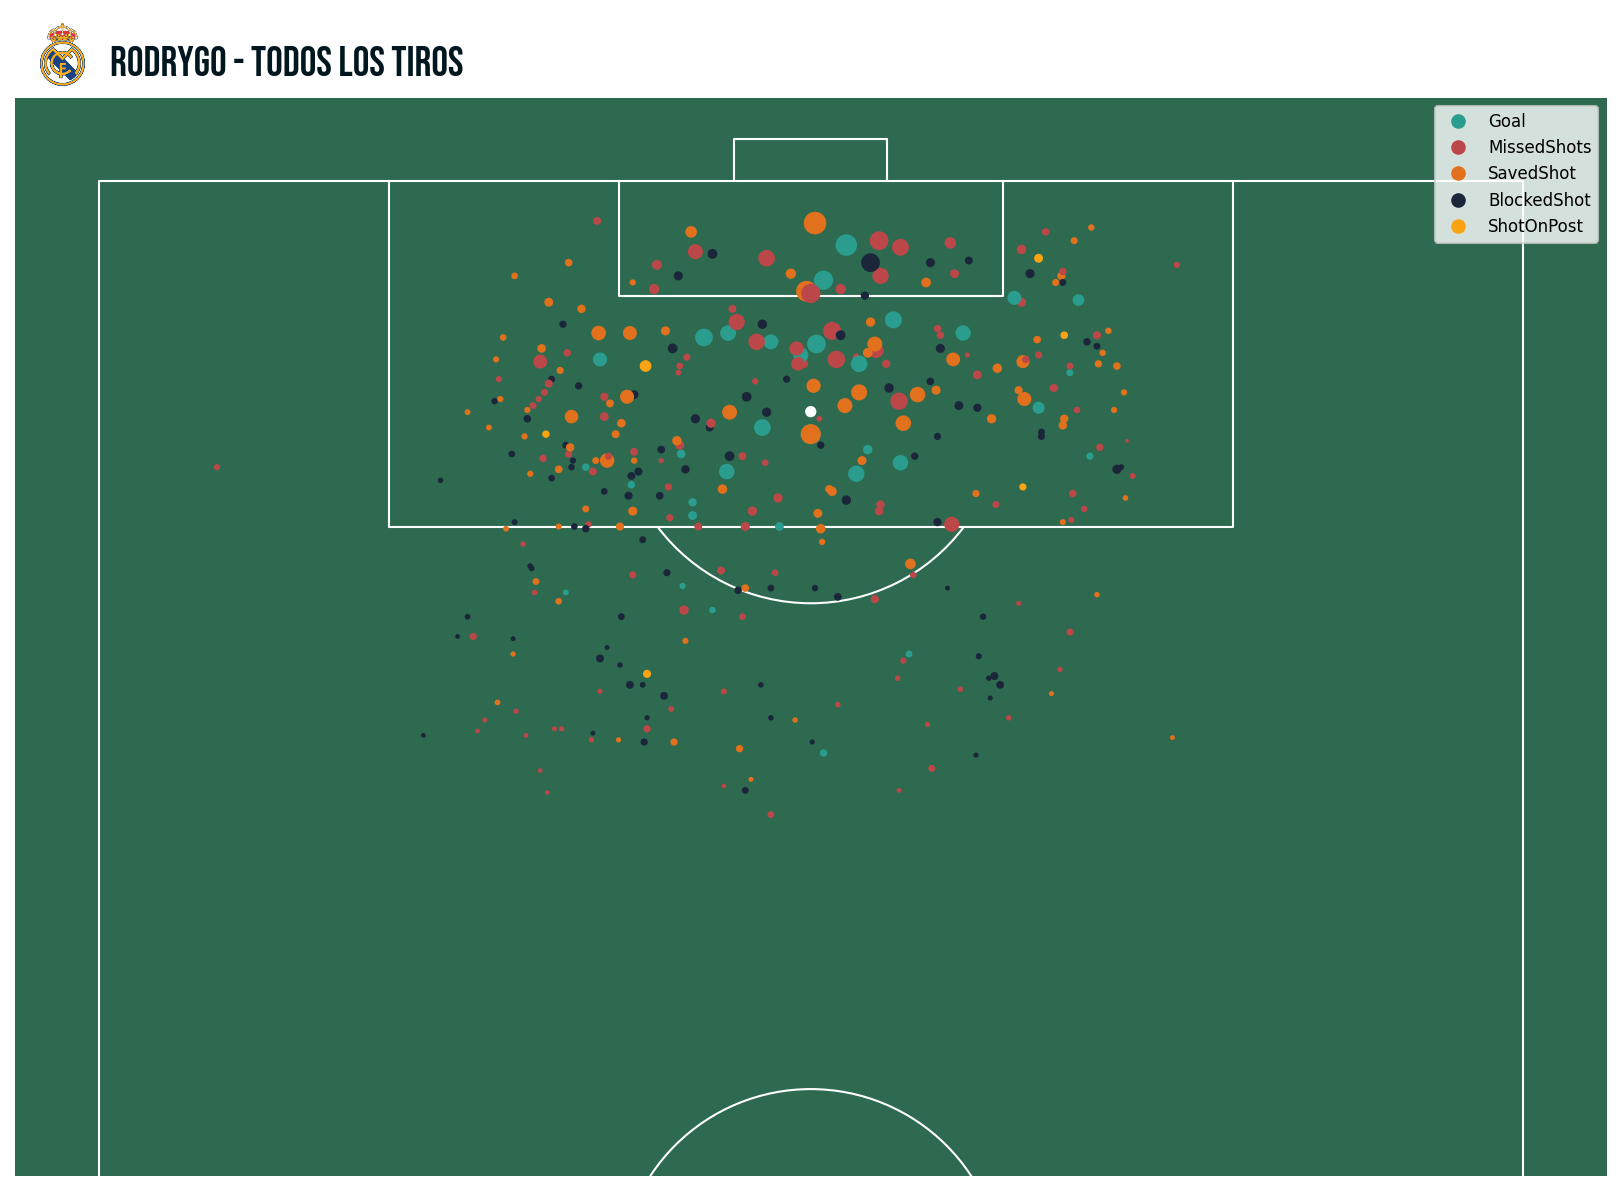

In [27]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

# Plot the Football Pitch where shots will be plotted
pitch = VerticalPitch(pitch_type='custom', half=True, pitch_color='#2d6a4f', line_color='white', linewidth=1, stripe=True,
                      stripe_color='#2d6a4f', pitch_length=105, pitch_width=68, goal_type='box', label=False, pad_bottom=-5)
pitch.draw(ax=ax)

# Plot the title image and the title
logo_url = df['Team_Logo'].iloc[0]
add_image_from_url(logo_url, x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left',va='bottom', s=title,fontproperties=font.prop,transform=ax.transAxes)

# Create a custom legend to define the types of shots
legend = {'Goal': '#2a9d8f', 'MissedShots': '#bc4749', 'SavedShot': '#e2711d', 'BlockedShot': '#1b263b', 'ShotOnPost': '#fca311'}

# Plot the shots on the pitch and map the color to the legend dictionary
pitch.scatter(df['X_scaled'], df['Y_scaled'],color=df['result'].map(legend), s=df['xG']*100, marker="o",ax=ax)

# Plot the legend for better interpretation of the chart
legendhandle = [ax.plot([], marker="o", ls="", color=color)[0] for color in list(legend.values())]
ax.legend(legendhandle,list(legend.keys()),loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()

#ax.invert_xaxis() #Y coordinates ar reversed if needed
#ax.invert_yaxis() #Y coordinates ar reversed if needed

### Mapa de tiros de todas las temporadas

In [17]:
def plot_shots_on_pitch(df, ax, title, logo_url=None, font=None):
    # Crear el pitch
    pitch = VerticalPitch(pitch_type='custom', half=True, pitch_color='#2d6a4f', line_color='white', linewidth=1, stripe=True,
                          stripe_color='#2d6a4f', pitch_length=105, pitch_width=68, goal_type='box', label=False, pad_bottom=-5)
    pitch.draw(ax=ax)

    # Añadir logo
    if logo_url is not None:
        add_image_from_url(logo_url, x_pos=0.06, y_pos=1.08, size=0.15, relative_to='axes')

    # Añadir título
    ax.text(x=0.12, y=1.04, s=title, fontproperties=font.prop, fontsize=16, color='#00171f', fontweight='bold',
        ha='left', va='bottom', transform=ax.transAxes)

    # Dibujar los tiros
    legend = {'Goal': '#2a9d8f', 'MissedShots': '#bc4749', 'SavedShot': '#e2711d', 'BlockedShot': '#1b263b', 'ShotOnPost': '#fca311'}
    pitch.scatter(df['X_scaled'], df['Y_scaled'], color=df['result'].map(legend), s=df['xG'] * 100, marker='o', ax=ax)

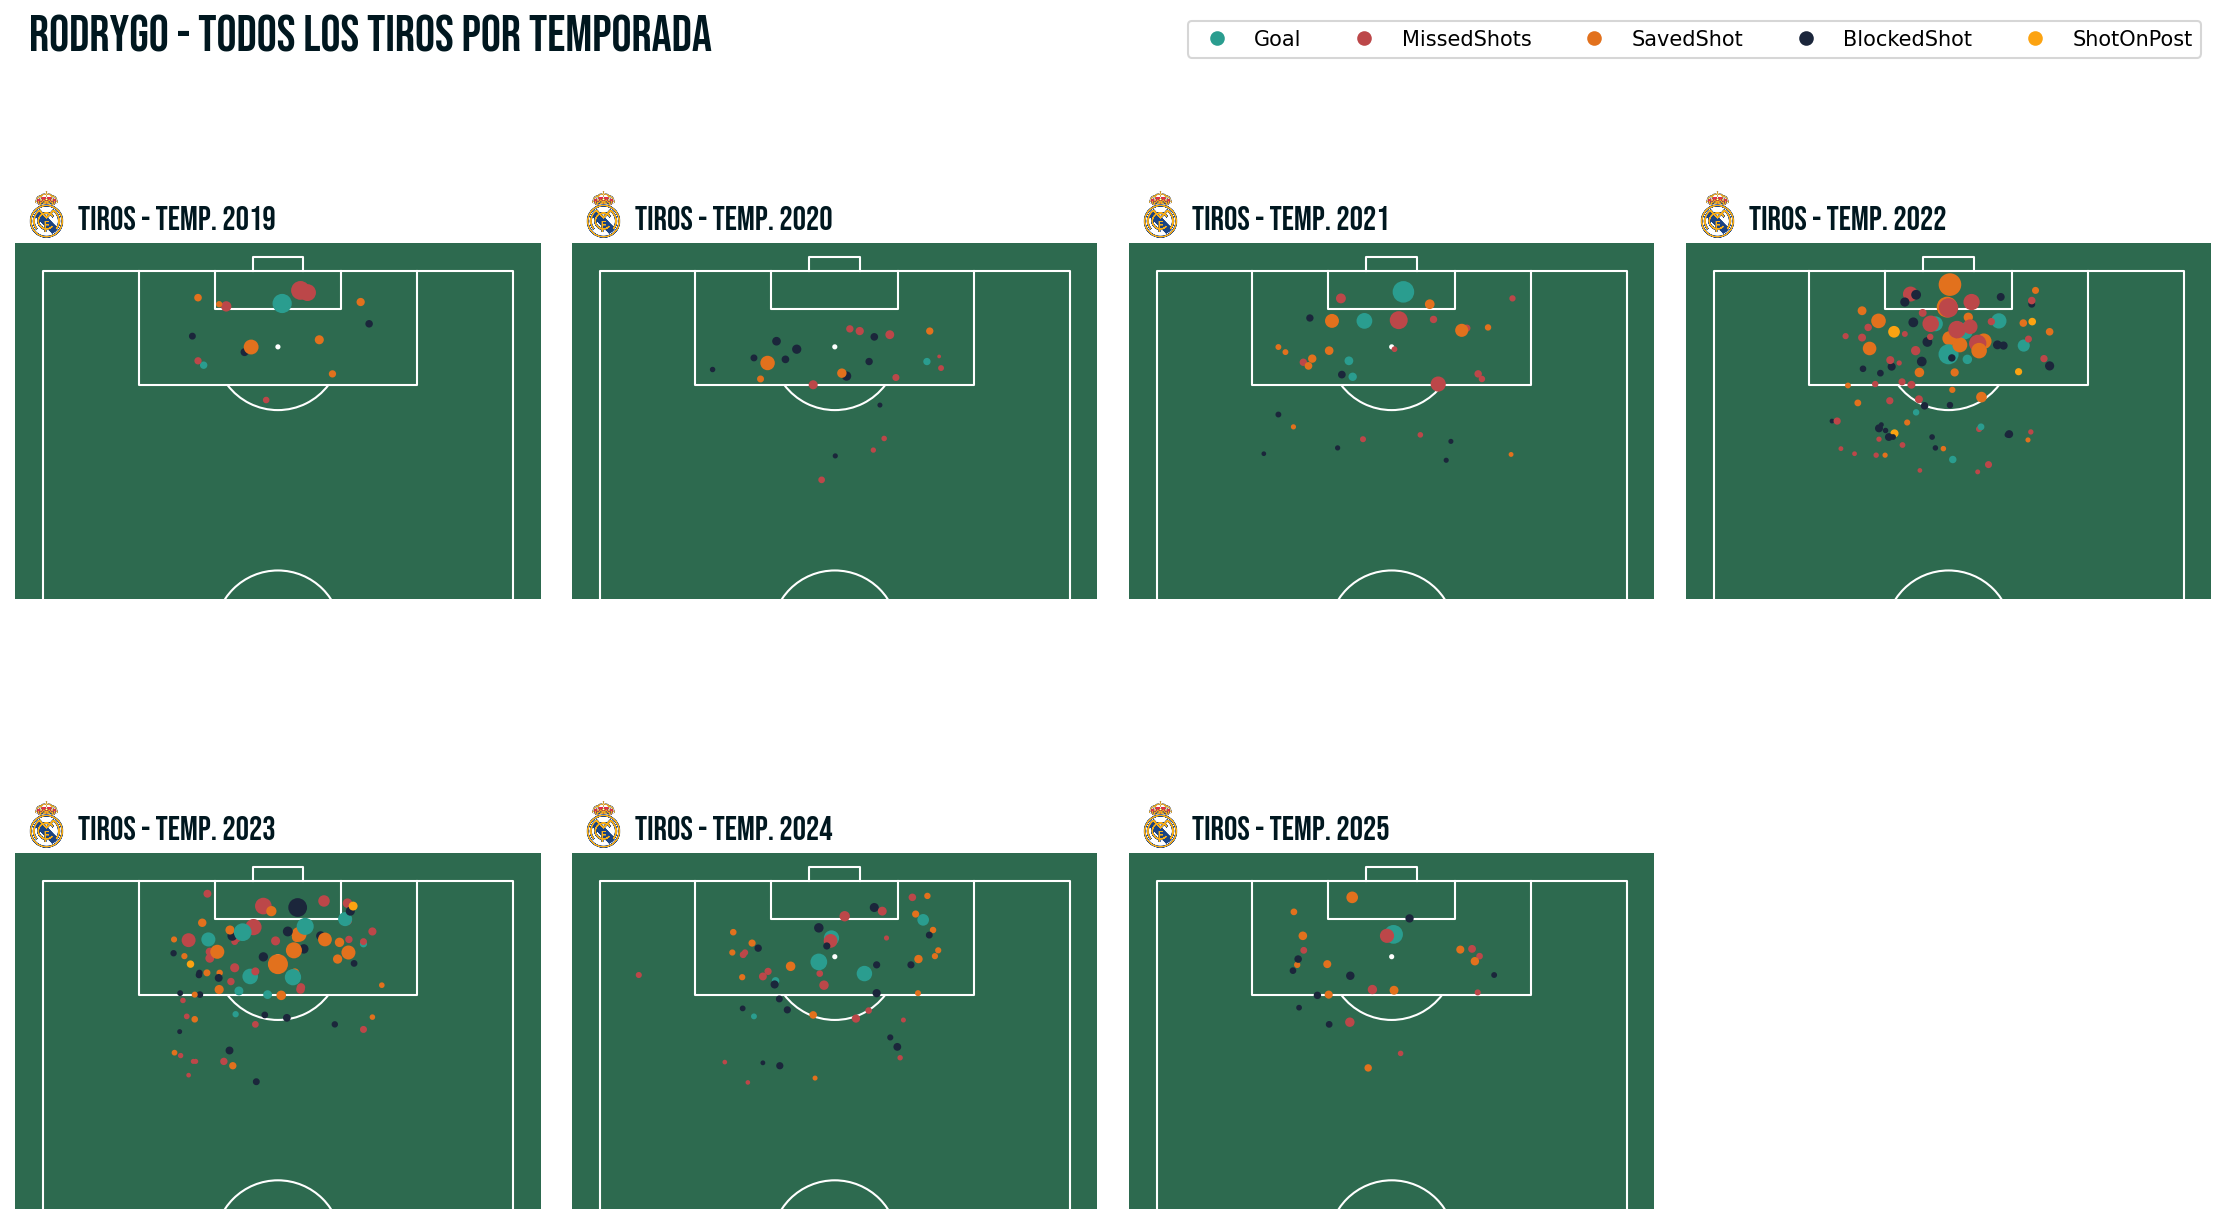

In [30]:
import math

seasons = df['season'].unique()
n = len(seasons)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15,9), dpi=150)

title = f'{df_shots['player'][0]} - Todos los tiros por temporada'
fig.text(x=0.02, y=1, s=title, fontproperties=font.prop, fontsize=24, color='#00171f', fontweight='bold',ha='left', va='bottom', transform=fig.transFigure)

for season, ax in zip(seasons, axs.flat):
    df_season = df[df['season'] == season]
    plot_shots_on_pitch(df_season, ax, title=f'Tiros - Temp. {season}', logo_url=df_season['Team_Logo'].iloc[0], font=font)

for ax in axs.flat[len(seasons):]:
    ax.remove()

# Leyenda
legendhandle = [ax.plot([], marker='o', ls='', color=color)[0] for color in list(legend.values())]
fig.legend(legendhandle, list(legend.keys()), loc='upper right', frameon=True, fontsize=10, ncol=len(legend), bbox_to_anchor=(0.99, 1.03))

plt.tight_layout()

### 2. MAPAS DE PASES - STATSBOMB

In [31]:
import pandas as pd
from mplsoccer import Pitch, FontManager, Sbopen
import math
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from PIL import Image
from io import BytesIO

In [32]:
game_id = 3857258

In [33]:
parser = Sbopen()

In [34]:
df_events = parser.event(game_id)[0][['timestamp','period','type_name','team_name','player_name','player_id','x','y','end_x','end_y','outcome_name','pass_recipient_name','pass_recipient_id']]


In [35]:
df_events['team_name'].unique()

array(['Brazil', 'Serbia'], dtype=object)

In [36]:
team = 'Brazil'

In [37]:
df_passes = df_events[(df_events['type_name'] == 'Pass') & (df_events['team_name'] == team)].reset_index(drop=True)

df_passes['outcome_name'] = df_passes['outcome_name'].fillna('Successful')
df_passes['outcome_name'] = df_passes['outcome_name'].replace({'Out': 'Missed', 'Incomplete': 'Missed', 'Injury Clearance': 'Missed', 'Unknown': 'Missed', 'Pass Offside': 'Missed'})


In [38]:
def add_image_from_url(url, x_pos, y_pos, size, relative_to):
    """
    Añade una imagen a un gráfico desde una URL.

    Parámetros:
    - url: Link de la imagen.
    - x_pos, y_pos: Posición en el gráfico.
    - size: Tamaño (zoom) de la imagen (ej: 0.1).
    - relative_to:
        * 'data': Usa los números de los ejes (ej: Goles).
        * 'axes': Usa el área del gráfico (0 a 1).
        * 'figure': Usa toda la imagen final (0 a 1).
    """
    # Descarga y procesa la imagen
    response = requests.get(url, timeout=5)
    img = Image.open(BytesIO(response.content)).convert('RGBA')

    # Define el sistema de coordenadas
    coord_style = relative_to if relative_to == 'data' else f'{relative_to} fraction'

    # Crea y añade la imagen al gráfico
    imagebox = OffsetImage(img, zoom=size)
    ax.add_artist(AnnotationBbox(imagebox, (x_pos, y_pos), xycoords=coord_style, frameon=False))

In [39]:
# Custom title font and image
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')

In [40]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')
df_passes = df_passes.merge(df_team_mapping[['Statsbomb', 'Team_Logo']],how='left',left_on='team_name',right_on='Statsbomb')
df_passes.drop(columns='Statsbomb', inplace=True)

In [44]:
title = f'Mapa de pases de {team}'
legend = {'Successful': '#0ead69','Missed': '#bc4749'}

In [42]:
df_passes.head()

,timestamp,period,type_name,team_name,player_name,player_id,x,y,end_x,end_y,outcome_name,pass_recipient_name,pass_recipient_id,Team_Logo
0,00:00:00.360000,1,Pass,Brazil,Richarlison de Andrade,3280.0,60.0,40.0,59.7,36.7,Successful,Neymar da Silva Santos Junior,4320.0,https://media.api-sports.io/football/teams/6.png
1,00:00:02.717000,1,Pass,Brazil,Neymar da Silva Santos Junior,4320.0,63.2,33.5,51.4,11.7,Successful,Alex Sandro Lobo Silva,6945.0,https://media.api-sports.io/football/teams/6.png
2,00:00:06.342000,1,Pass,Brazil,Alex Sandro Lobo Silva,6945.0,56.7,9.8,51.6,24.3,Successful,Carlos Henrique Casimiro,5539.0,https://media.api-sports.io/football/teams/6.png
3,00:00:09.553000,1,Pass,Brazil,Carlos Henrique Casimiro,5539.0,46.8,20.6,37.6,23.4,Successful,Thiago Emiliano da Silva,3295.0,https://media.api-sports.io/football/teams/6.png
4,00:00:14.612000,1,Pass,Brazil,Thiago Emiliano da Silva,3295.0,38.6,28.1,38.7,7.2,Successful,Alex Sandro Lobo Silva,6945.0,https://media.api-sports.io/football/teams/6.png


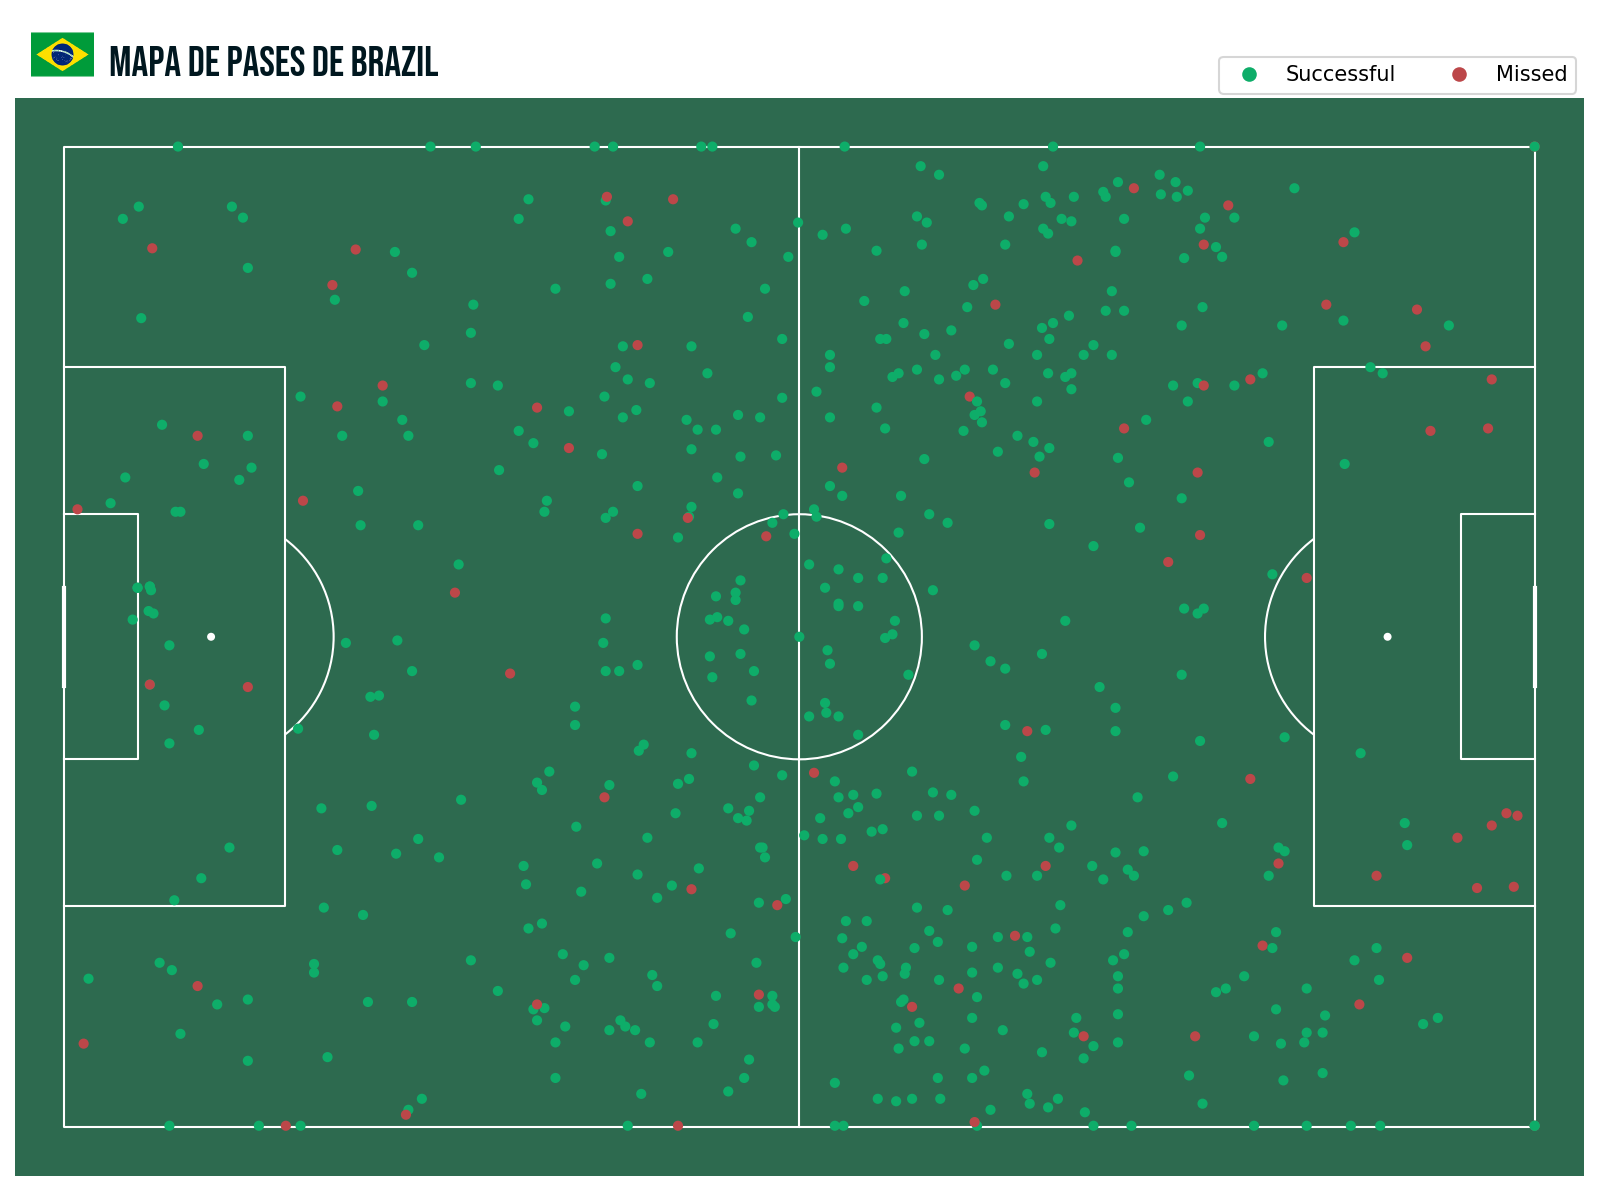

In [45]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

# Plot the pitch
pitch = Pitch(pitch_type='statsbomb', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

# Plot the title image and the title
add_image_from_url(df_passes['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title, fontproperties=font.prop, transform=ax.transAxes)

#Dibujamos el punto de inicio de los pases
pitch.scatter(x = df_passes['x'], y = df_passes['y'], color = df_passes['outcome_name'].map(legend), s = 15, marker = "o", ax=ax)

legendhandle = [ax.plot([], marker='o', ls='', color=color)[0] for color in list(legend.values())]
fig.legend(legendhandle, list(legend.keys()), frameon=True, fontsize=10, ncol=len(legend), bbox_to_anchor=(0.85, 0.96))

plt.tight_layout()

Mapa de campo horizontal y lineas de pases en forma de flechas

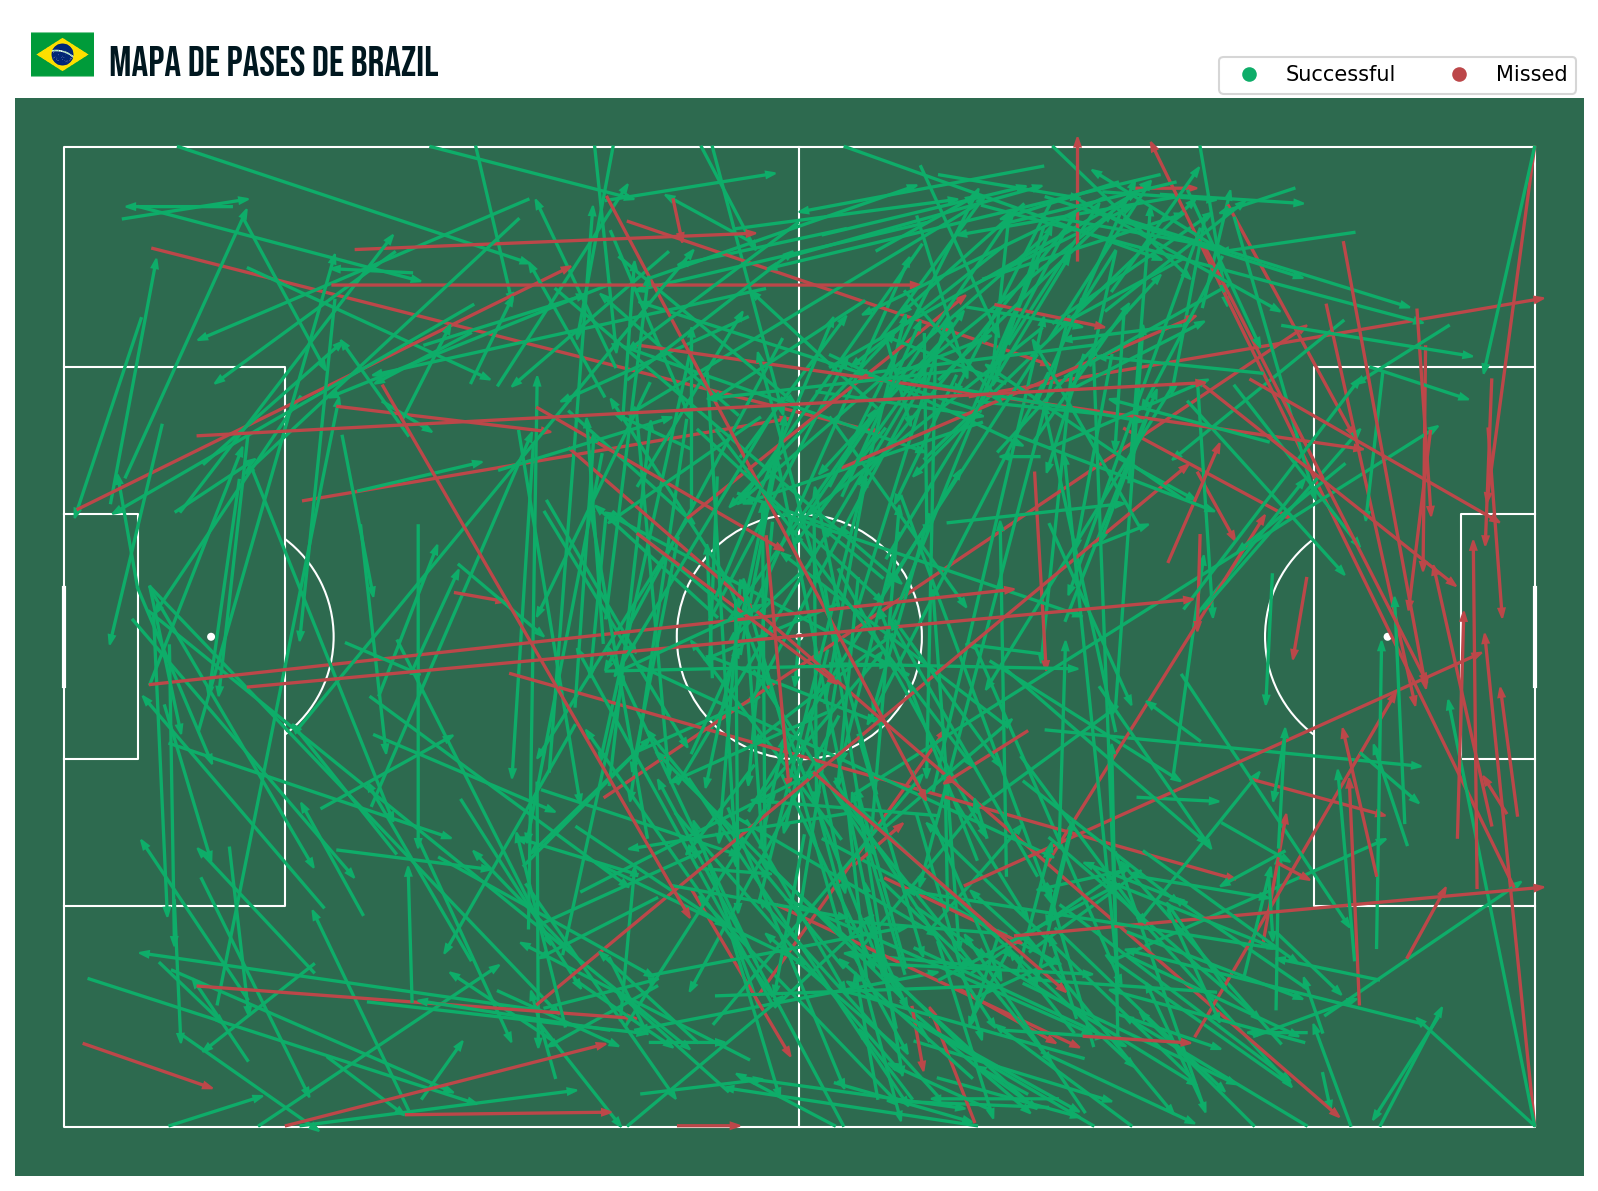

In [46]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

# Plot the pitch
pitch = Pitch(pitch_type='statsbomb', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

# Plot the title image and the title
add_image_from_url(df_passes['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title, fontproperties=font.prop, transform=ax.transAxes)

#Dibujamos pases como flechas
for i in range(len(df_passes)):
    ax.arrow(df_passes['x'][i], df_passes['y'][i],
                  df_passes['end_x'][i] - df_passes['x'][i],
                  df_passes['end_y'][i] - df_passes['y'][i],
                  head_width = 0.5, width = 0.1,
                  ec = df_passes['outcome_name'].map(legend)[i], color=df_passes['outcome_name'].map(legend)[i], alpha = 1)

legendhandle = [ax.plot([], marker='o', ls='', color=color)[0] for color in list(legend.values())]
fig.legend(legendhandle, list(legend.keys()), frameon=True, fontsize=10, ncol=len(legend), bbox_to_anchor=(0.85, 0.96))

plt.tight_layout()

#### Mapa de campo horizontal y lineas de pases en forma cometa

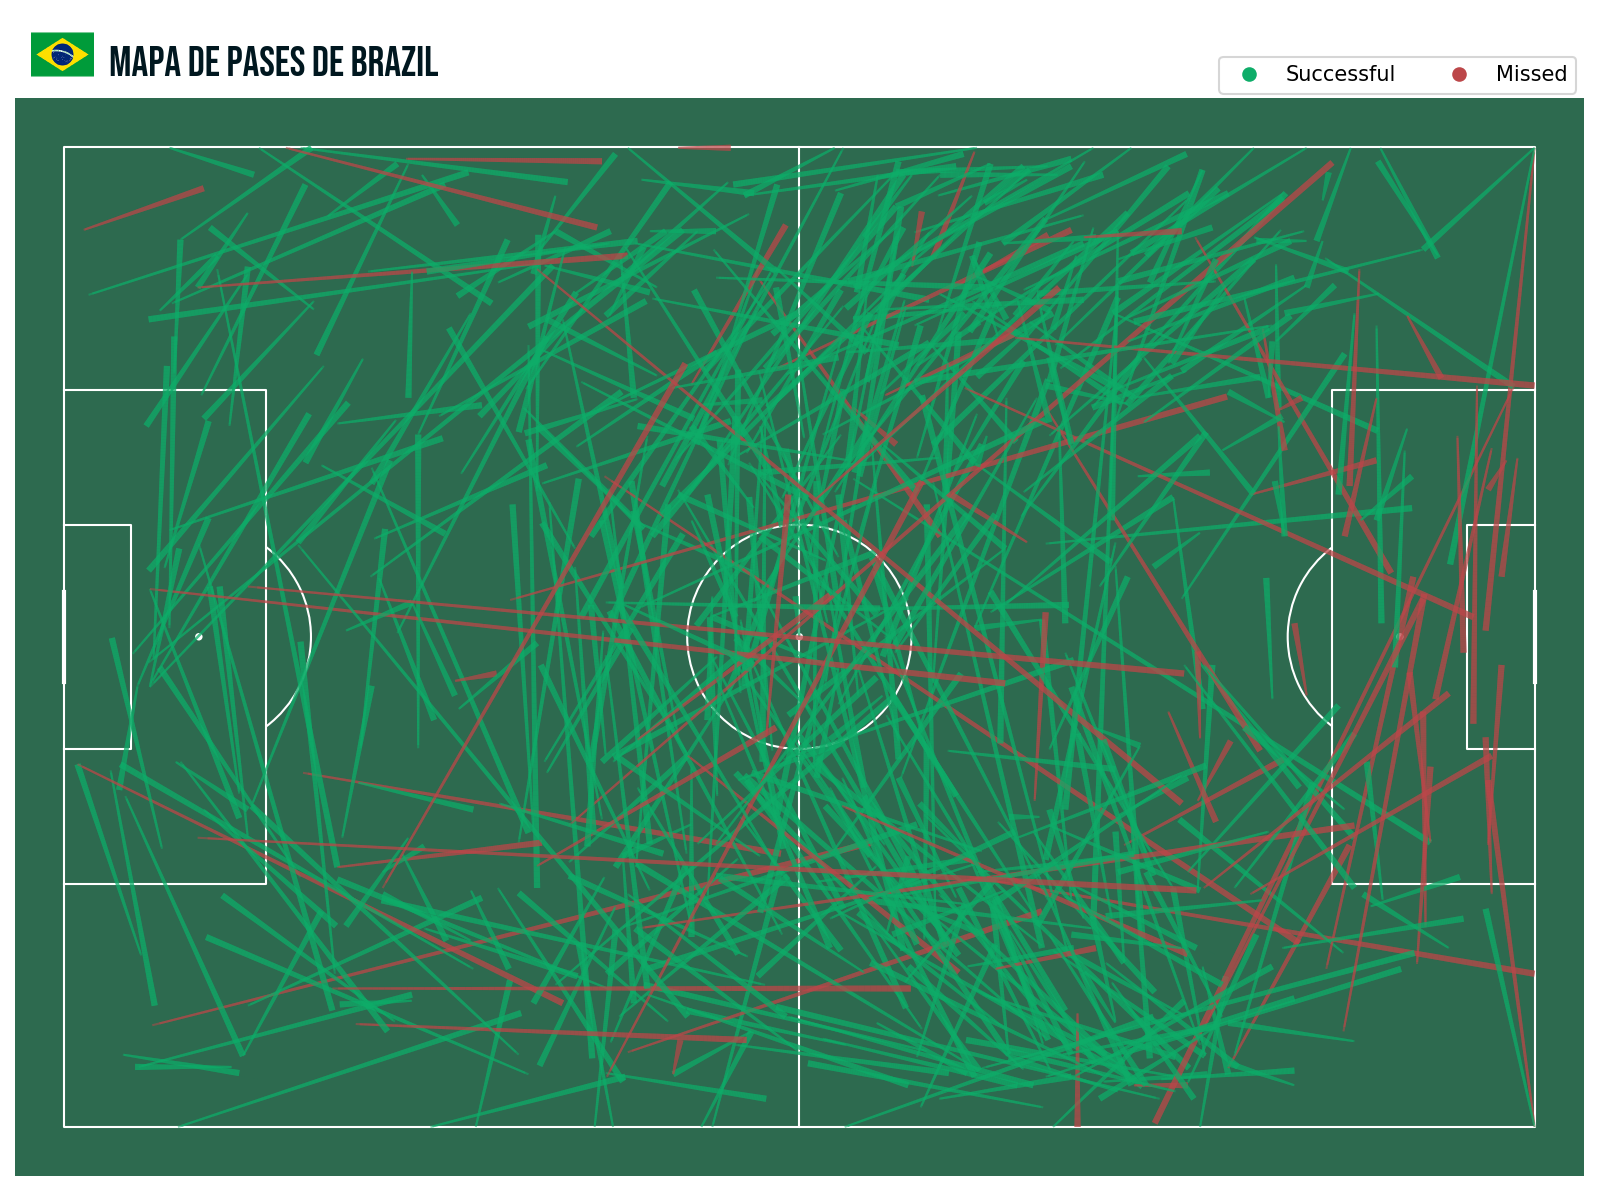

In [47]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

# Plot the pitch
pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,
              pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

# Plot the title image and the title
add_image_from_url(df_passes['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')

ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title, fontproperties=font.prop, transform=ax.transAxes)

#Plot como cometa
for i in range(len(df_passes)):
    pitch.lines(xstart = df_passes['x'][i],
                ystart = df_passes['y'][i],
                xend = df_passes['end_x'][i],
                yend = df_passes['end_y'][i],
                ec = df_passes['outcome_name'].map(legend)[i],
                color=df_passes['outcome_name'].map(legend)[i],
                alpha = 0.5,
                linewidth=3,
                comet=True,
                ax=ax)

legendhandle = [ax.plot([], marker='o', ls='', color=color)[0] for color in list(legend.values())]
fig.legend(legendhandle, list(legend.keys()), frameon=True, fontsize=10, ncol=len(legend), bbox_to_anchor=(0.85, 0.96))

plt.tight_layout()

### Un mapa de pases por jugador del equipo

In [48]:
# Obtener jugadores que han hecho al menos 10 pases
pases_por_jugador = df_passes.groupby('player_name').size()
jugadores_validos = pases_por_jugador[pases_por_jugador >= 5].index
df_passes = df_passes[df_passes['player_name'].isin(jugadores_validos)].reset_index(drop=True)

In [54]:
fig_title = f'Mapa de pases de los jugadores de {team}'

In [52]:
def plot_passes(df, ax_title, ax, font, pitch_color='#2d6a4f'):

    # Crear el campo
    pitch = Pitch(pitch_type='custom', half=False, pitch_color=pitch_color,line_color='white', linewidth=1,pitch_length=120, pitch_width=80,goal_type='line', label=False)
    pitch.draw(ax=ax)
    ax.invert_yaxis()

    # Título del subplot
    ax.text(x=0, y=1.02,fontsize=14, color='#00171f', fontweight='bold',ha='left', va='bottom', s=ax_title, fontproperties=font.prop, transform=ax.transAxes)

    for _, row in df.iterrows():
        color = legend.get(row['outcome_name'], '#999')
        pitch.lines(xstart=row['x'], ystart=row['y'],
                    xend=row['end_x'], yend=row['end_y'],
                    ec=color, color=color, alpha=0.5,
                    linewidth=3, comet=True, ax=ax)

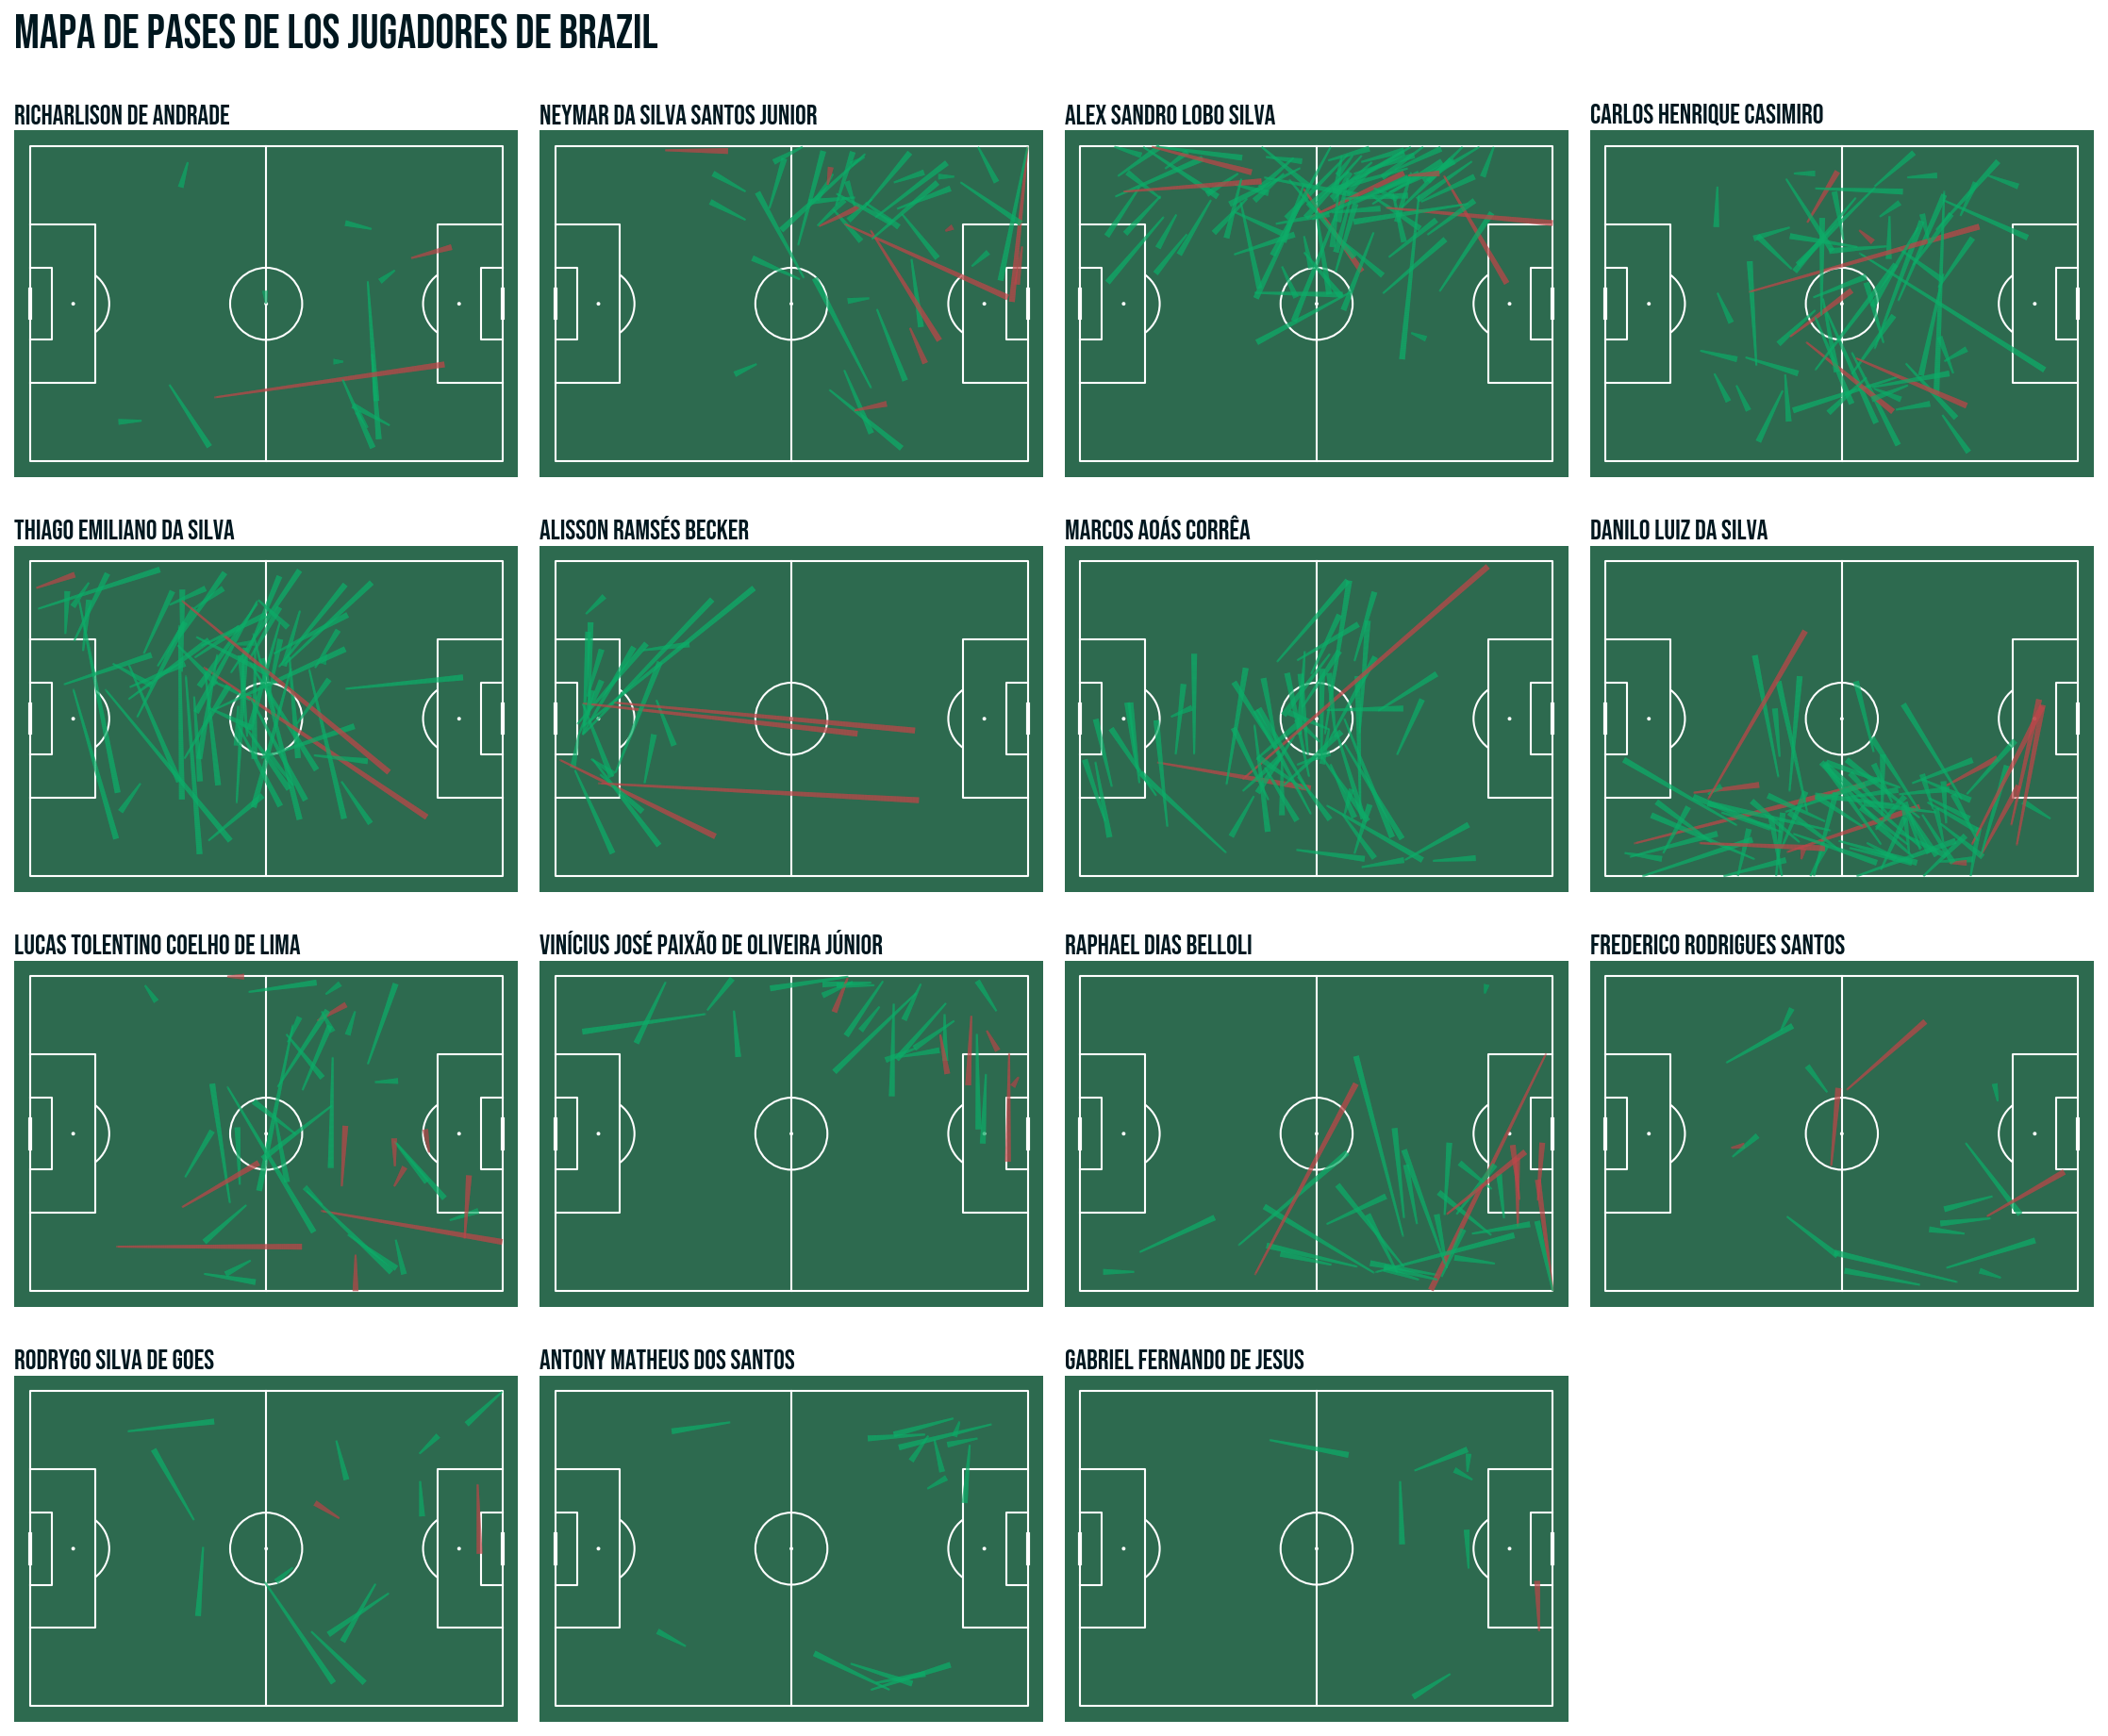

In [55]:
import math

players = df_passes['player_name'].unique()

n = len(players)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 12), dpi=150)

# Logo y título general
fig.text(x=0.01, y=1.015, s=fig_title, fontproperties=font.prop, fontsize=24,color='#00171f', fontweight='bold', ha='left', va='bottom', transform=fig.transFigure)

for player, ax in zip(players, axs.flat):
    df_player = df_passes[df_passes['player_name'] == player].copy()
    plot_passes(df_player, player, ax, font)

# Oculta ejes vacíos si hay más subplots que jugadores
for ax in axs.flat[len(players):]:
    ax.remove()

plt.tight_layout()

## 3. Tercios y carriles - Stastbomb

In [56]:
game_id = 3857258

In [57]:
parser = Sbopen()

In [58]:
df_events = parser.event(game_id)[0][['timestamp','period','type_name','team_name','player_name','x','y']]

In [59]:
df_events['team_name'].unique()

array(['Brazil', 'Serbia'], dtype=object)

In [60]:
team = 'Brazil'

In [61]:
df = df_events[(df_events['type_name'] == 'Pass') & (df_events['team_name'] == team)].reset_index(drop=True)

In [ ]:
# funcion para ajustar imagen
# def add_image_from_url

In [62]:
# Custom title and image
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')

In [63]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')
df = df.merge(df_team_mapping[['Statsbomb', 'Team_Logo']],how='left',left_on='team_name',right_on='Statsbomb')
df.drop(columns='Statsbomb', inplace=True)

#### Cuadrantes tercios o carriles (vertical u horizontal)

In [64]:
# Aquí definimos cuantos cuadrantes queremos analizar (vertical o tercios, horizontal o carriles)
bins = (1, 3) # Podemos elegir entre tercios y carriles cambiando de orden el 1 y el 3
colors = ["#032215", "#118A3E"]

In [69]:
title = 'Mapa de carriles (nº pases)'

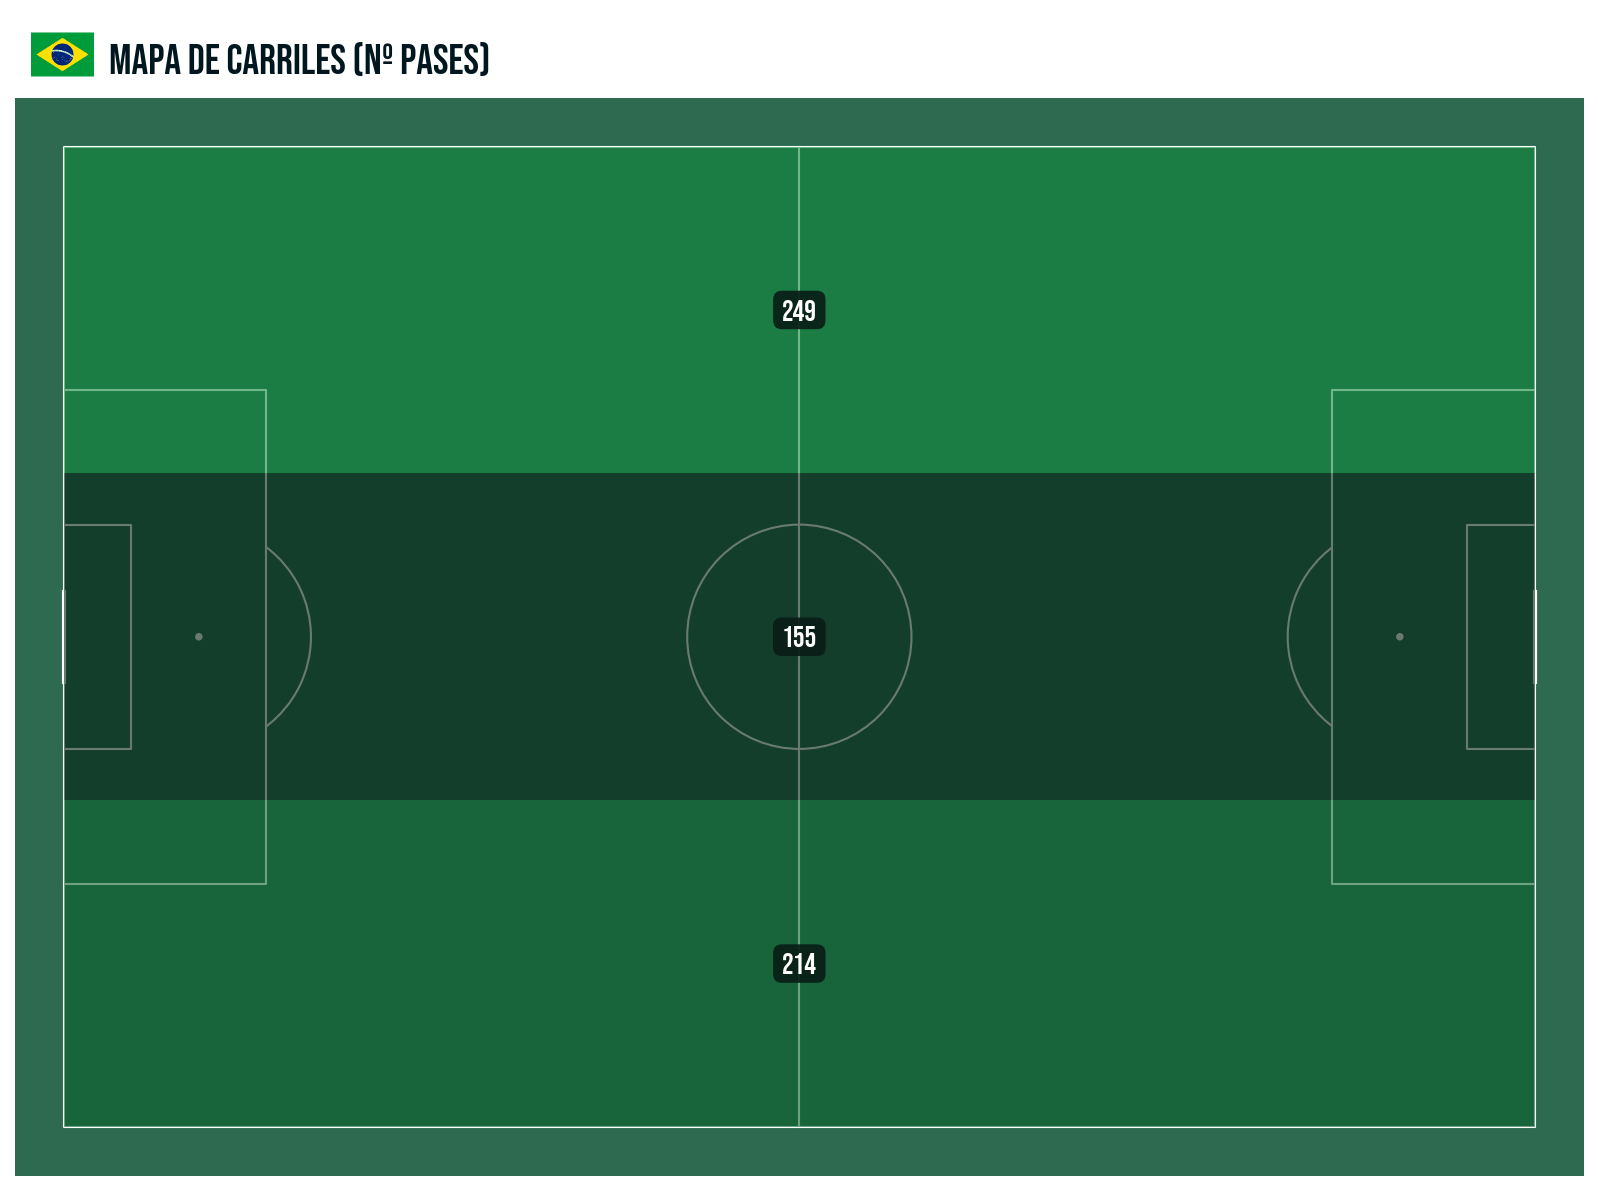

In [70]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() #Y coordinates ar reversed tof it Statsbomb coordinate system in the visualization

# Plot the title image and the title
add_image_from_url(df['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title, fontproperties=font.prop, transform=ax.transAxes)

colormap = LinearSegmentedColormap.from_list('colormap', colors, N=100)
bs_heatmap = pitch.bin_statistic(df.x, df.y, statistic='count', bins=bins)

str_format='{0:.0f}' # para quitar el %

pitch.heatmap(bs_heatmap, ax=ax, cmap=colormap, alpha=0.6)
#pitch.scatter(df['x'], df['y'], s=6, marker="o", color = '#081c15', ax=ax)
pitch.label_heatmap(bs_heatmap, color='white', ax=ax, str_format=str_format,
                    ha='center', va='center', fontproperties=font.prop, fontsize=14, weight="bold",
                    bbox=dict(facecolor='#081c15', edgecolor='none', alpha=0.9, boxstyle="round,pad=0.3"))

plt.tight_layout()

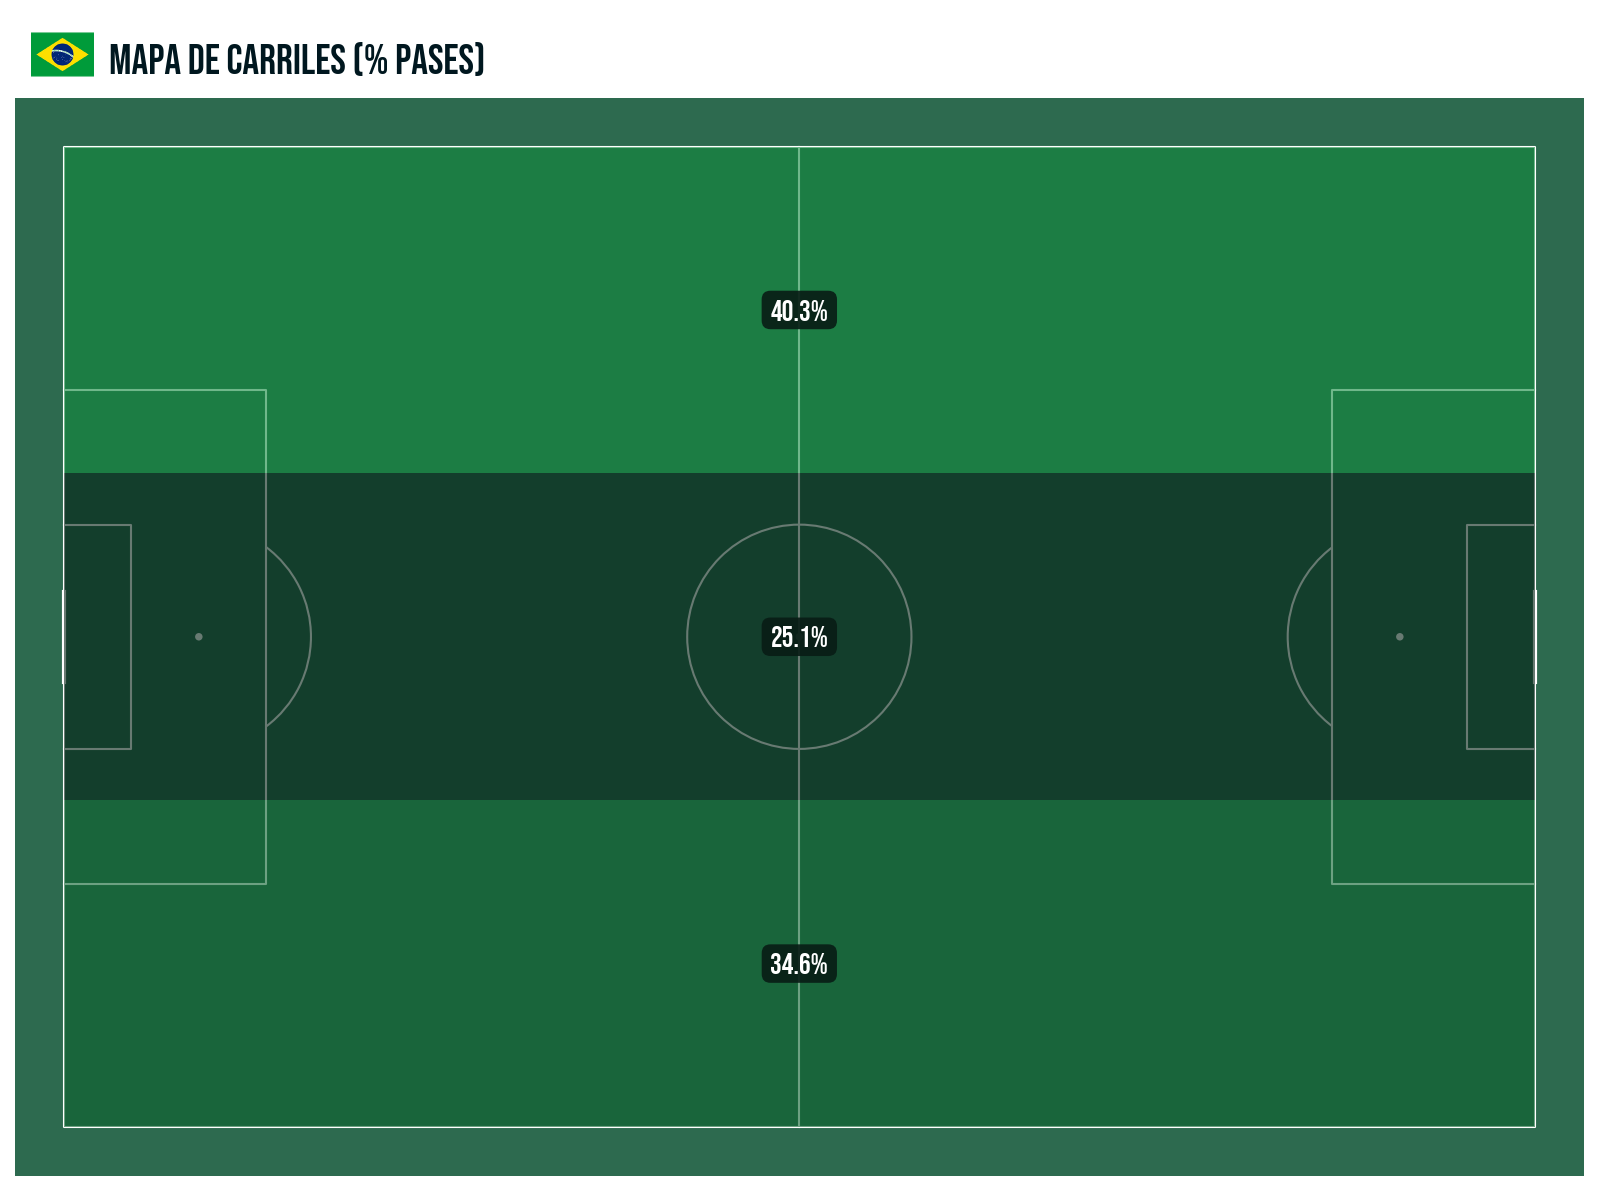

In [71]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)
title = 'Mapa de carriles (% pases)'
pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() #Y coordinates ar reversed tof it Statsbomb coordinate system in the visualization

# Plot the title image and the title
add_image_from_url(df['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title, fontproperties=font.prop, transform=ax.transAxes)

colormap = LinearSegmentedColormap.from_list('colormap', colors, N=100)
bs_heatmap = pitch.bin_statistic(df.x, df.y, statistic='count', bins=bins)

# Normalizar los valores para que sean % del total
total = bs_heatmap['statistic'].sum()
bs_heatmap['statistic'] = (bs_heatmap['statistic'] / total) * 100  # porcentaje
str_format='{0:.1f}%' # con el símbolo de %

pitch.heatmap(bs_heatmap, ax=ax, cmap=colormap, alpha=0.6)
#pitch.scatter(df['x'], df['y'], s=6, marker="o", color = '#081c15', ax=ax)
pitch.label_heatmap(bs_heatmap, color='white', ax=ax, str_format=str_format,
                    ha='center', va='center', fontproperties=font.prop, fontsize=14, weight="bold",
                    bbox=dict(facecolor='#081c15', edgecolor='none', alpha=0.9, boxstyle="round,pad=0.3"))

plt.tight_layout()

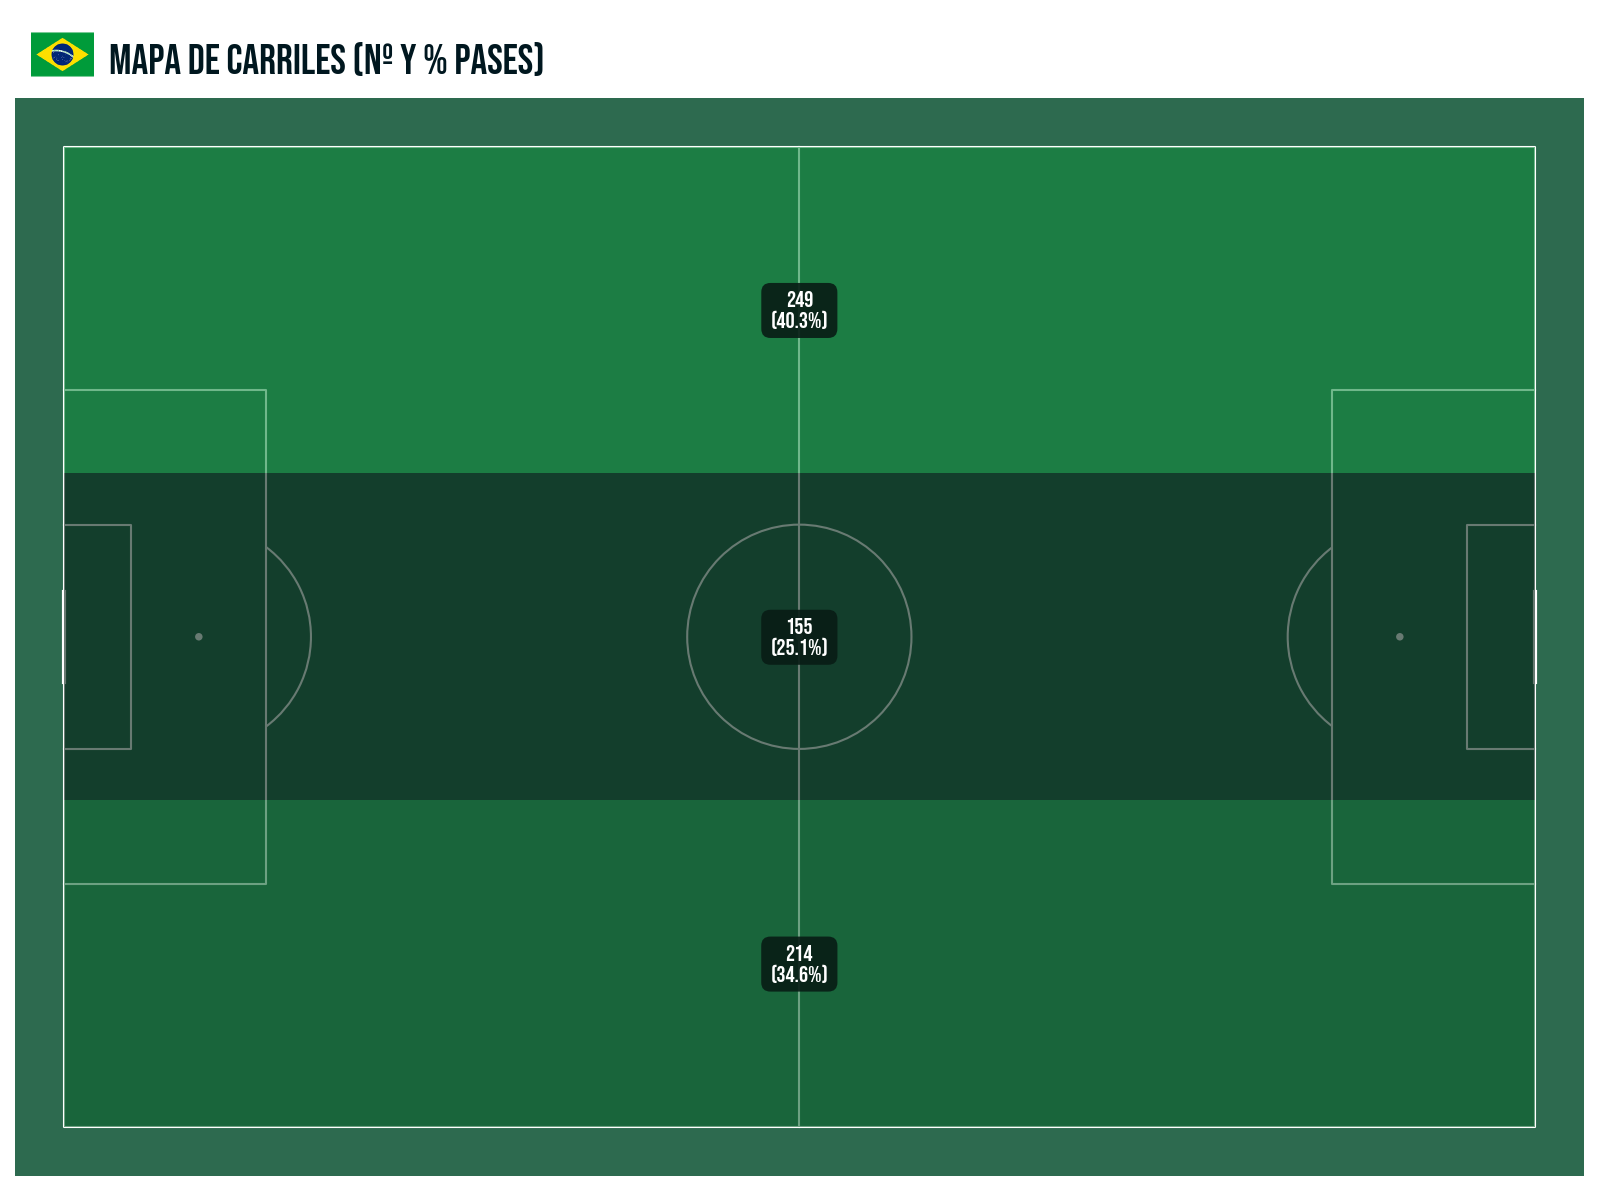

In [72]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)
title = 'Mapa de carriles (Nº y % pases)'
pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white',
              linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() #Y coordinates ar reversed tof it Statsbomb coordinate system in the visualization

# Plot the title image and the title
add_image_from_url(df['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', s=title,
        fontproperties=font.prop, transform=ax.transAxes)

colormap = LinearSegmentedColormap.from_list('colormap', colors, N=100)
bs_heatmap = pitch.bin_statistic(df.x, df.y, statistic='count', bins=bins)

# 1. Conservamos los conteos absolutos antes de normalizar
conteos_absolutos = bs_heatmap['statistic'].copy()

# 2. Normalizamos los valores para obtener el porcentaje
total = conteos_absolutos.sum()
bs_heatmap['statistic'] = (conteos_absolutos / total) * 100  # porcentaje

# 3. Dibujamos el mapa de calor normalmente
pitch.heatmap(bs_heatmap, ax=ax, cmap=colormap, alpha=0.6)

# 4. Dibujamos las etiquetas de forma manual iterando celda por celda
filas, columnas = bs_heatmap['statistic'].shape

for i in range(filas):
    for j in range(columnas):
        abs_val = conteos_absolutos[i, j]
        pct_val = bs_heatmap['statistic'][i, j]

        # Omitimos pintar texto en las zonas vacías para que no se sature el mapa
        if abs_val > 0:
            # Combinamos el entero absoluto y el porcentaje con un salto de línea (\n)
            texto_celda = f"{int(abs_val)}\n({pct_val:.1f}%)"

            # Usamos ax.text aprovechando los centros calculados por mplsoccer (cx y cy)
            ax.text(
                bs_heatmap['cx'][i, j],
                bs_heatmap['cy'][i, j],
                texto_celda,
                color='white',
                ha='center',
                va='center',
                fontproperties=font.prop,
                fontsize=11,          # Un punto menos para que quepa bien en dos renglones
                weight="bold",
                bbox=dict(
                    facecolor='#081c15',
                    edgecolor='none',
                    alpha=0.9,
                    boxstyle="round,pad=0.4" # Un pad ligeramente mayor para el doble renglón
                )
            )

plt.tight_layout()

## 4. Heatmaps - STATSBOMB

In [73]:
game_id = 3857258

In [74]:
parser = Sbopen()

In [75]:
df_events = parser.event(game_id)[0][['timestamp','period','type_name','team_name','player_name','x','y']]

In [76]:
df_events['team_name'].unique()

array(['Brazil', 'Serbia'], dtype=object)

In [77]:
team = 'Brazil'

In [78]:
df = df_events[(df_events['type_name'] == 'Pass') & (df_events['team_name'] == team)].reset_index(drop=True)

In [ ]:
# funcion para ajustar imagen
# def add_image_from_url

In [82]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')
df = df.merge(df_team_mapping[['Statsbomb', 'Team_Logo']],how='left',left_on='team_name',right_on='Statsbomb')
df.drop(columns='Statsbomb', inplace=True)

In [88]:
# Titulo e imagen
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')
title = f'{team} - Mapa de calor'

In [80]:
bins = (19, 12) # Number of bins in the pitch
#colors = ["#000000", "#118A3E"]
colors = ["#118A3E", "#000000"]

### Mapa de calor

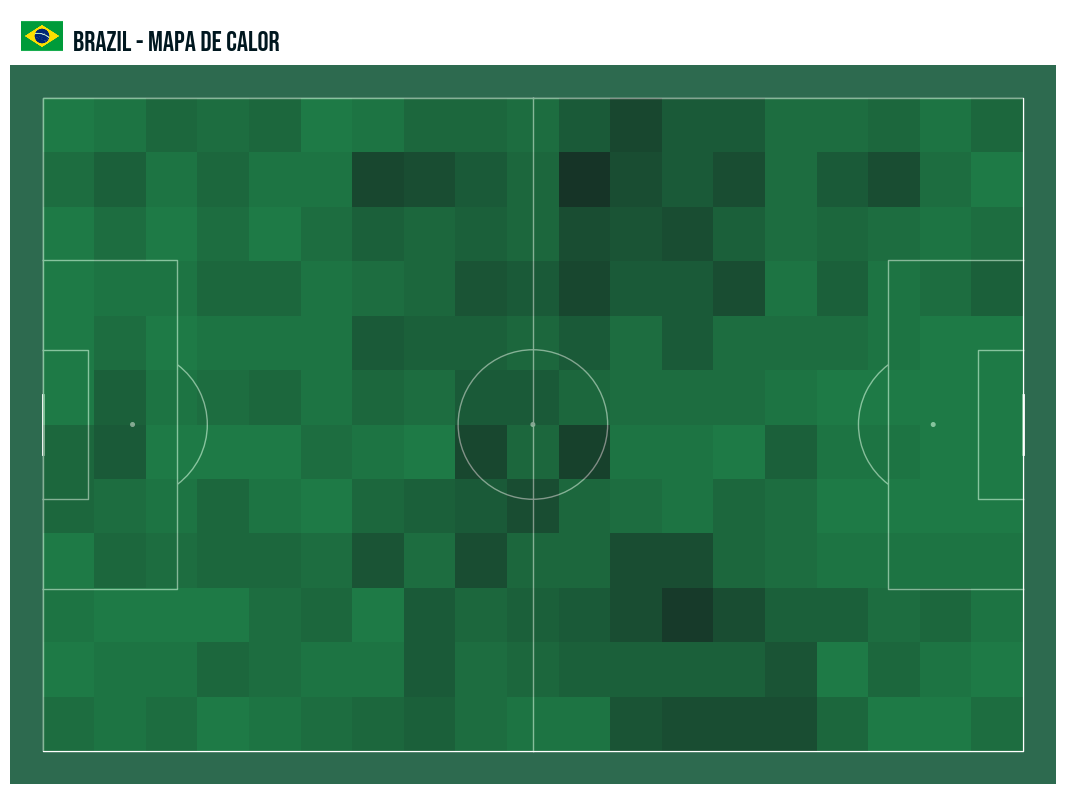

In [89]:
fig, ax = plt.subplots(figsize=(15,8), dpi=100)

pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

# Plot the title image and the title
add_image_from_url(df['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, s=title, fontproperties=font.prop, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', transform=ax.transAxes)

colormap = LinearSegmentedColormap.from_list("custom_cmap", colors)
bs_heatmap = pitch.bin_statistic(df.x, df.y, statistic='count', bins=bins)
pitch.heatmap(bs_heatmap, ax=ax, cmap=colormap, alpha=0.5)
#mostrar los puntos de los pases
#pitch.scatter(df['x'], df['y'], s=6, marker="o", color = 'white', ax=ax)
# mostrar el numero de pases en cada cuadrante
#pitch.label_heatmap(bs_heatmap, color='#F84D04', ax=ax, str_format='{0:.0f}', ha='center', va='center', fontsize=10, weight="bold")

plt.tight_layout()

#### Mapa de calor granular

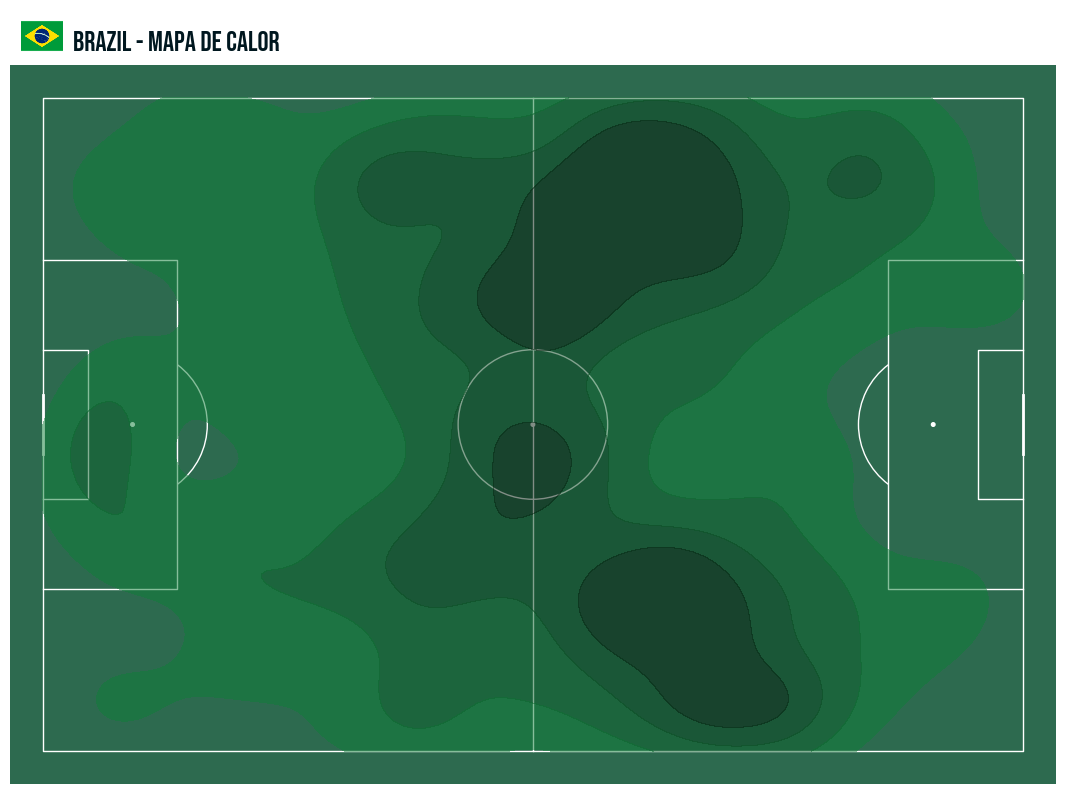

In [90]:
fig, ax = plt.subplots(figsize=(15,8), dpi=100)

pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis

# Plot the title image and the title
add_image_from_url(df['Team_Logo'][0], x_pos=0.03, y_pos=1.04, size=0.2, relative_to='axes')
ax.text(x=0.06, y=1.02, s=title, fontproperties=font.prop, fontsize=20, color='#00171f', fontweight='bold',ha='left', va='bottom', transform=ax.transAxes)

colormap = LinearSegmentedColormap.from_list("custom_cmap", colors)
pitch.kdeplot(df['x'],df['y'], ax=ax, cmap=colormap, fill=True, levels=5, alpha=0.5, bw_method=0.2)

plt.tight_layout()

## 5. Convex Hull - STATSBOMB

In [101]:
from scipy.spatial import ConvexHull

In [92]:
game_id = 3857258

In [93]:
parser = Sbopen()

In [94]:
df_events = parser.event(game_id)[0][['id','period','type_name','team_name','player_name','player_id','x','y','position_name']]

In [95]:
df = df_events[df_events['type_name'] == 'Pass'].reset_index(drop=True)
df = df[df['position_name'].notna() & (df['position_name'] != 'Goalkeeper')] # Keep only starting 11 without goalkeeper
df = df.groupby(['team_name', 'player_name', 'player_id'])[['x', 'y']].mean().reset_index()

In [96]:
df_team_mapping = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/PROFESIONAL/Visualizaciones/Providers_Team_Mapping.xlsx')
df = df.merge(df_team_mapping[['Statsbomb', 'Team_Color']],how='left',left_on='team_name',right_on='Statsbomb')
df.drop(columns='Statsbomb', inplace=True)

In [103]:
# Custom title font and image
font = FontManager('https://github.com/google/fonts/blob/main/ofl/bebasneue/BebasNeue-Regular.ttf?raw=true')
title = 'CONVEX HULL'

In [99]:
teams = df['team_name'].unique() # Get team names and store them
team_colors = df['Team_Color'].unique() # Get team color and store it

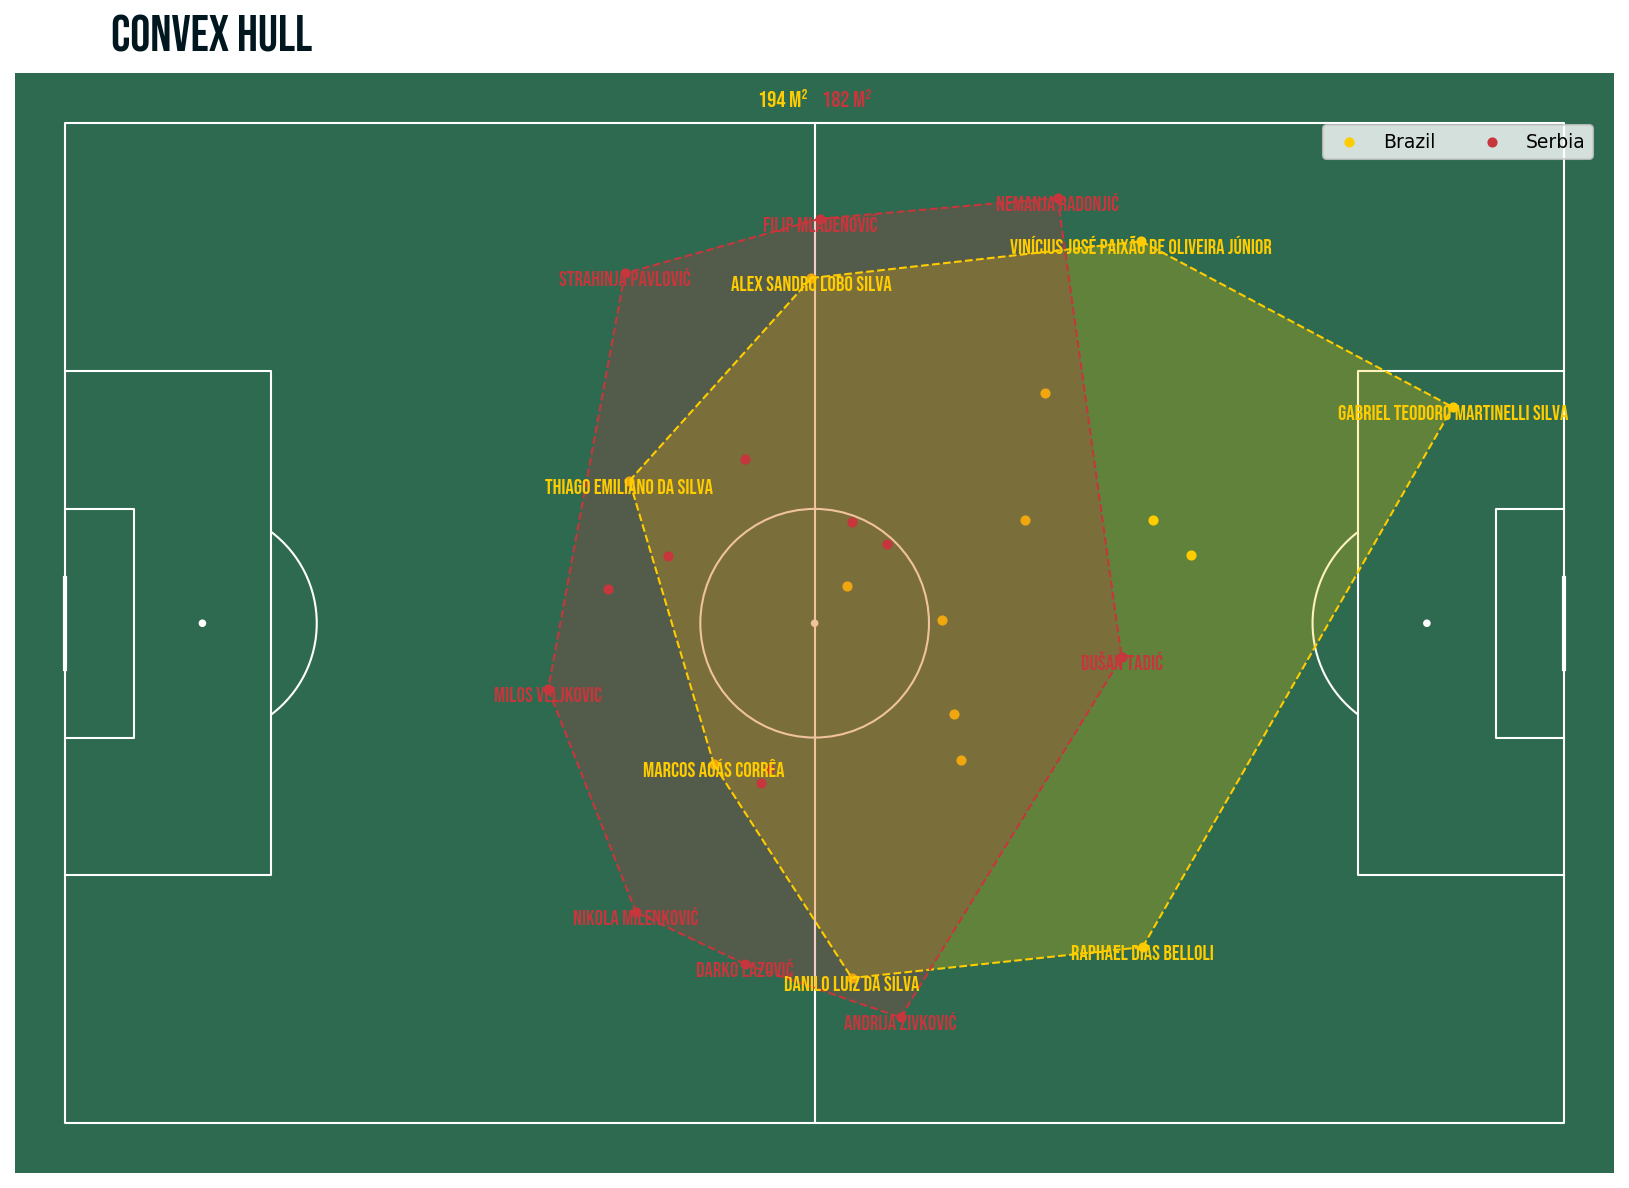

In [106]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

# Plot the pitch
pitch = Pitch(pitch_type='custom', half = False, pitch_color='#2d6a4f', line_color='white', linewidth = 1,pitch_length=120, pitch_width=80, goal_type='line', label=False)

pitch.draw(ax=ax)
ax.invert_yaxis() # Invert Y axis


# Imagen a la izq. del título
#add_image_from_url(logo_url, x_pos=0.03, y_pos=1.04, size=0.1, relative_to='axes')
ax.text(x=0.06, y=1.02, s=title, fontproperties=font.prop, fontsize=24, color='#00171f', fontweight='bold',ha='left', va='bottom', transform=ax.transAxes)

# Iterate over the teams
for i, team in enumerate(teams):
    team_df = df[df['team_name'] == team].reset_index(drop=True)
    points = team_df[['x', 'y']].values

    hull = ConvexHull(points)

    # Plot the area of each team
    ax.text(0.48 + i*0.04, 0.97, f'{hull.area:.0f} m²', color=team_colors[i],fontsize=11, transform=ax.transAxes, fontproperties=font.prop, ha='center')

    # Plot the external dots
    ax.scatter(team_df['x'], team_df['y'], color=team_colors[i], s=15, label=team)

    # Plot the perimeter of the hull
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], '--', lw=1, c=team_colors[i])

    # Fill the hull (shadow)
    ax.fill(points[hull.vertices, 0], points[hull.vertices, 1], team_colors[i], alpha=0.25)

    # Plot player names
    for idx in hull.vertices:
        ax.text(team_df['x'][idx], team_df['y'][idx] + 1, team_df['player_name'][idx],
                color=team_colors[i], fontsize=10, ha='center',fontproperties=font.prop)


fig.legend(loc='upper right', frameon=True, fontsize=9, bbox_to_anchor=(0.85, 0.90), ncol=len(teams))

plt.tight_layout()